In [1]:
from utils import *
from plotting import *
from visualisations import *
from numerical import *
import sympy as sp

saver = FigureSaver(base_folder="figures/PartII/Kerr", fmt="pdf", dpi=400, timestamp=False)

## 3. The Kerr Metric

The **Kerr metric** describes the geometry of spacetime around a rotating, uncharged mass.  
It is a stationary, axisymmetric, and asymptotically flat vacuum solution of Einstein's field equations,  
parameterized by the mass $M$ and the specific angular momentum $a = J/M$.

In Boyer–Lindquist coordinates $(t, r, \theta, \phi)$, the line element reads

$$
ds^2 = -\left(1 - \frac{2Mr}{\Sigma}\right) dt^2 
        - \frac{4Mar \sin^2\theta}{\Sigma}\, dt\, d\phi
        + \frac{\Sigma}{\Delta}\, dr^2 
        + \Sigma\, d\theta^2
        + \left(r^2 + a^2 + \frac{2Ma^2 r \sin^2\theta}{\Sigma}\right)\sin^2\theta\, d\phi^2,
$$

where $\Sigma = r^2 + a^2 \cos^2\theta$ and $\Delta = r^2 - 2Mr + a^2$.

---

### 4-velocities in Kerr (Boyer–Lindquist)

We work with the Kerr metric in Boyer–Lindquist coordinates $(t,r,\theta,\phi)$, with
$\Sigma = r^2 + a^2\cos^2\theta$ and $\Delta = r^2 - 2Mr + a^2$. The nonzero metric components we need are
$$
g_{tt} = -\!\left(1 - \frac{2Mr}{\Sigma}\right), \qquad
g_{t\phi} = -\frac{2Mar\sin^2\theta}{\Sigma}, \qquad
g_{\phi\phi} = \left(r^2 + a^2 + \frac{2Ma^2 r \sin^2\theta}{\Sigma}\right)\sin^2\theta.
$$

---

#### Stationary observer (fixed $r,\theta,\phi$; only outside the ergosphere)

A stationary observer follows the Killing flow $\partial_t$:
$$
u^\mu_{\text{stat}} = \left(u^t,\,0,\,0,\,0\right), 
\qquad
u^t = \frac{1}{\sqrt{-\,g_{tt}}}
\quad \text{(requires } g_{tt}<0 \text{)}.
$$

Covariant components:
$$
u_{\mu}^{\text{stat}} = g_{\mu\nu} u^\nu_{\text{stat}}
\; \Rightarrow \;
u_t = g_{tt}\,u^t, \qquad
u_\phi = g_{t\phi}\,u^t, \qquad
u_r = u_\theta = 0.
$$

---

#### Rotating circular observer at angular velocity $\Omega$  (constant $r,\theta$)

Take worldlines with $d\phi/dt = \Omega$:
$$
u^\mu(\Omega) = u^t(\Omega)\,\left(1,\,0,\,0,\,\Omega\right),
\qquad
u^t(\Omega) = \frac{1}{\sqrt{-\big(g_{tt} + 2\Omega\,g_{t\phi} + \Omega^2 g_{\phi\phi}\big)}},
$$
so that $u^\mu u_\mu = -1$. Covariant components:
$$
u_t = \big(g_{tt} + \Omega\,g_{t\phi}\big)\,u^t, 
\qquad
u_\phi = \big(g_{t\phi} + \Omega\,g_{\phi\phi}\big)\,u^t,
\qquad
u_r = u_\theta = 0.
$$

---

#### Geodesic circular orbits in the equatorial plane ($\theta=\pi/2$): $\Omega_\pm$

For prograde/retrograde **geodesic** circular motion (equatorial),
$$
\Omega_{\pm} = \frac{\pm\,\sqrt{M}}{\,r^{3/2} \pm a\sqrt{M}\,}
\quad \big(\;G=c=1\;\big),
$$
giving the 4-velocity
$$
u^\mu_{\pm} = u^t(\Omega_\pm)\,\left(1,\,0,\,0,\,\Omega_\pm\right),
\qquad
u^t(\Omega_\pm) = \frac{1}{\sqrt{-\big(g_{tt} + 2\Omega_\pm g_{t\phi} + \Omega_\pm^{2} g_{\phi\phi}\big)}}.
$$

> Notes:  
> • Stationary observers exist only where $g_{tt}<0$ (outside the ergosphere).  
> • ZAMOs correspond to $\Omega = \omega \equiv -g_{t\phi}/g_{\phi\phi}$ and are timelike even inside the ergosphere.  


In [2]:
Mval, aval = 1.0, 0.9
theta = np.pi/2
rs = np.linspace(2.1, 20.0, 200)

In [3]:
data = compare_observers(
    Mval=1.0,        # black-hole mass parameter
    aval=0.9,        # spin parameter (|a| ≤ M)
    theta=np.pi/2,   # equatorial plane
    N=500,           # number of sampling points
    rmax_factor=3,  # r_max ≈ 10 * r_min (adjust if needed)
    global_rmax_cap=40.0  # optional absolute upper bound
)

In [4]:
for obs, vals in data.items():
    print(f"{obs:10s}: r_min={vals['r_min']:.2f}, r_max={vals['r_max']:.2f}")

static    : r_min=2.00, r_max=6.00
prograde  : r_min=2.32, r_max=6.97
retrograde: r_min=8.72, r_max=26.16


=== STATIC OBSERVER ===
[FigureSaver] Saved figure → figures/PartII/Kerr\E2-B2 Comparison - Static.pdf


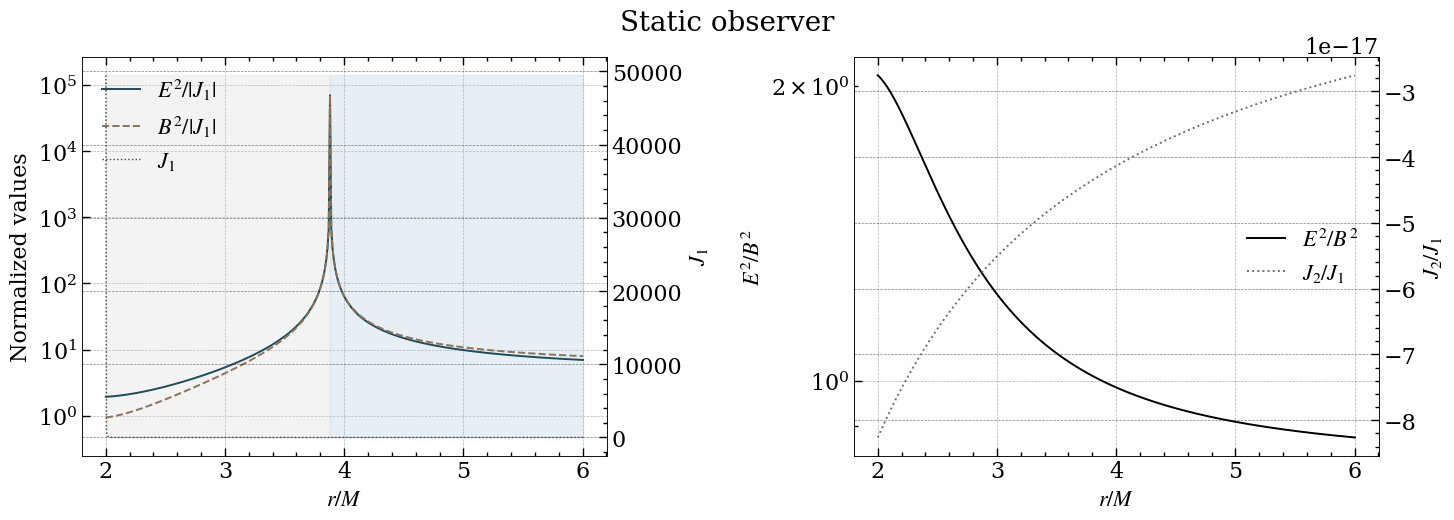

In [5]:
vals = data['static']

print("=== STATIC OBSERVER ===")
plot_ratios(vals['r'], vals['E2'], vals['B2'], vals['J1'], vals['J2'],
            title='Static observer', legend_loc1="upper left")
saver.save("E2-B2 Comparison - Static")
plt.show()

[FigureSaver] Saved figure → figures/PartII/Kerr\J1-J2 - Static.pdf


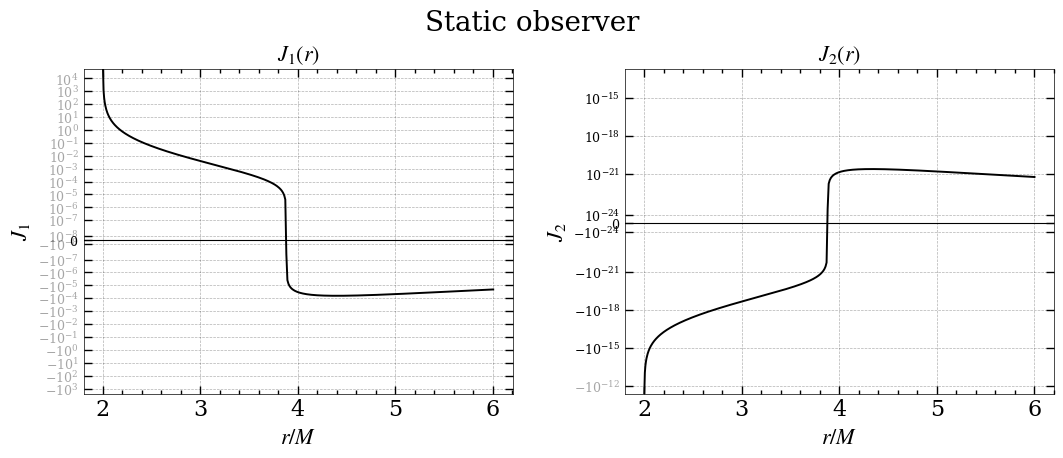

In [6]:
plot_Js(vals['r'], vals['J1'], vals['J2'], title='Static observer')
saver.save("J1-J2 - Static")
plt.show()

=== PROGRADE OBSERVER ===
[FigureSaver] Saved figure → figures/PartII/Kerr\E2-B2 Comparison - Prograde.pdf


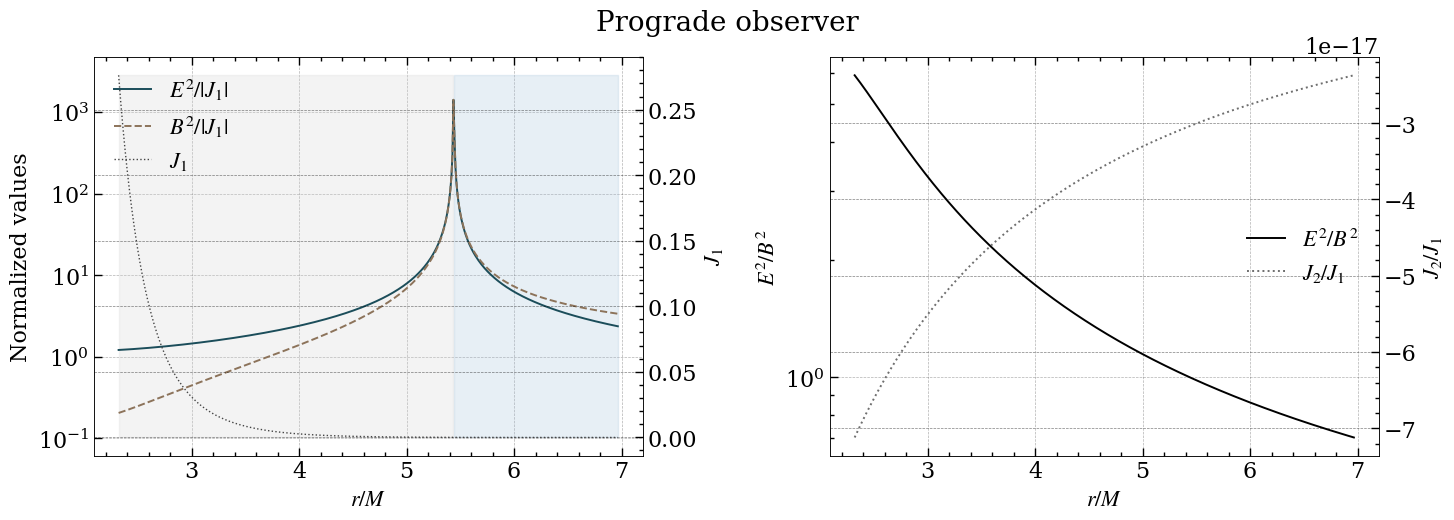

In [7]:
vals = data['prograde']

print("=== PROGRADE OBSERVER ===")
plot_ratios(vals['r'], vals['E2'], vals['B2'], vals['J1'], vals['J2'],
            title='Prograde observer', legend_loc1="upper left")
saver.save("E2-B2 Comparison - Prograde")
plt.show()

[FigureSaver] Saved figure → figures/PartII/Kerr\J1-J2 - Prograde.pdf


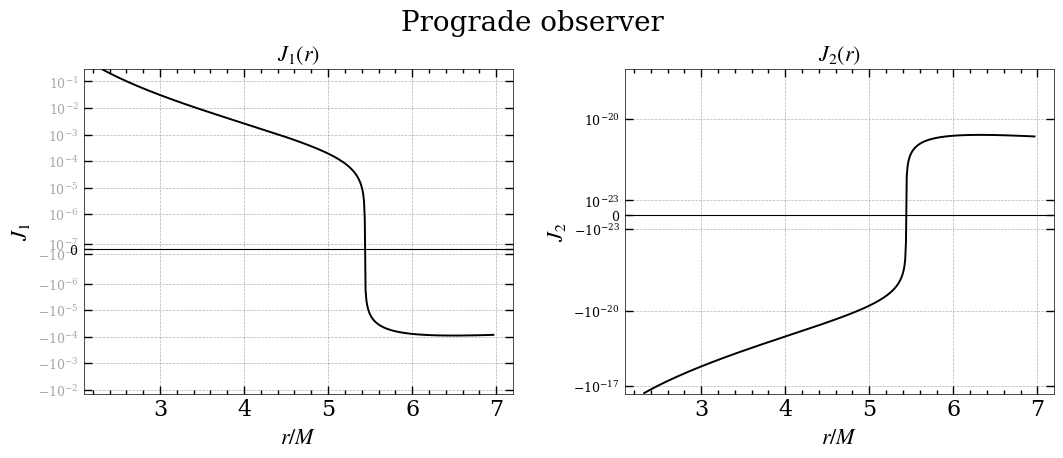

In [8]:
plot_Js(vals['r'], vals['J1'], vals['J2'], title='Prograde observer')
saver.save("J1-J2 - Prograde")
plt.show()

=== RETROGRADE OBSERVER ===
[FigureSaver] Saved figure → figures/PartII/Kerr\E2-B2 Comparison - Retrograde.pdf


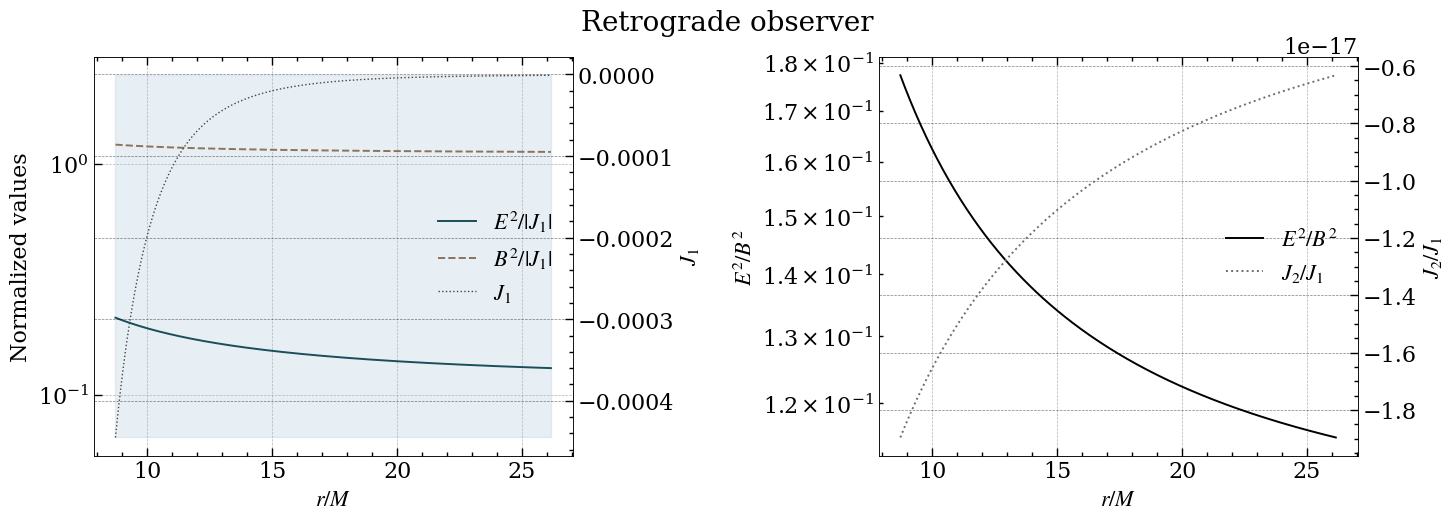

In [9]:
vals = data['retrograde']

print("=== RETROGRADE OBSERVER ===")
plot_ratios(vals['r'], vals['E2'], vals['B2'], vals['J1'], vals['J2'],
            title='Retrograde observer')
saver.save("E2-B2 Comparison - Retrograde")
plt.show()

[FigureSaver] Saved figure → figures/PartII/Kerr\J1-J2 - Retrograde.pdf


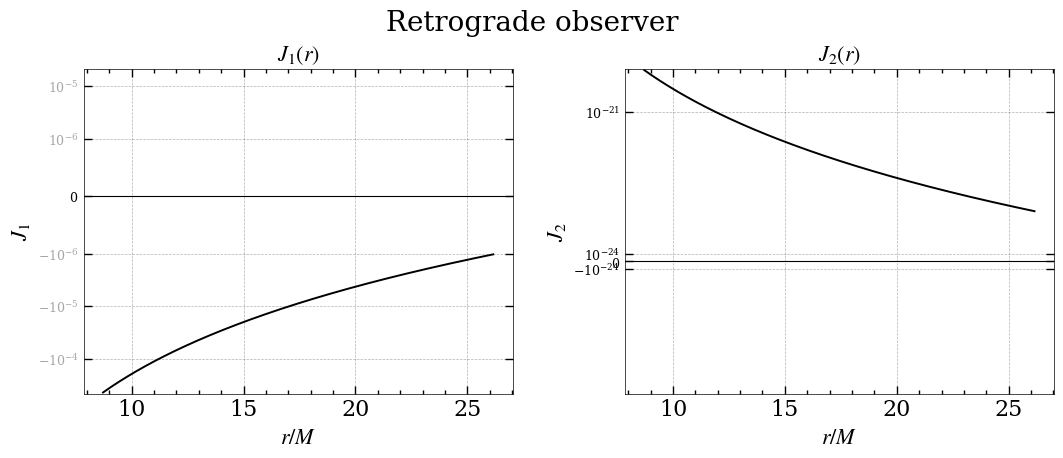

In [10]:
plot_Js(vals['r'], vals['J1'], vals['J2'], title='Retrograde observer')
saver.save("J1-J2 - Retrograde")
plt.show()